## Importing Dependencies

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Constrained Realizations Into Dataframe

In [2]:
filename = "/scratch/sackah/constrainedBaryonicMilkyWay_1ktrees.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "nodeLabelLMC",
    "nodeLabelIsLMCSubhalo",
    "nodeLabelWasLMCSubhalo",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
    "darkMatterOnlyRadiusVirial",
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

tree_id = np.full(len(constrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

constrained_df["tree_id"] = tree_id

constrained_df["absolute_distance"] = np.linalg.norm(
    constrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)


constrained_df = constrained_df[constrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(constrained_df["nodeIsIsolated"].value_counts())
print(constrained_df["tree_id"].max())
constrained_df.describe()

Number of nodeData columns: 61

Columns being loaded:
satellitePositionX (923383,) float64
satellitePositionY (923383,) float64
satellitePositionZ (923383,) float64
basicMass (923383,) float64
nodeIndex (923383,) int64
parentIndex (923383,) int64
nodeLabelLMC (923383,) int64
nodeLabelIsLMCSubhalo (923383,) int64
nodeLabelWasLMCSubhalo (923383,) int64
basicTimeLastIsolated (923383,) float64
nodeIsIsolated (923383,) int64
satelliteBoundMass (923383,) float64
darkMatterProfileScale (923383,) float64
darkMatterOnlyRadiusVirial (923383,) float64
nodeIsIsolated
0    922383
Name: count, dtype: int64
1000


,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,parentIndex,nodeLabelLMC,nodeLabelIsLMCSubhalo,nodeLabelWasLMCSubhalo,basicTimeLastIsolated,nodeIsIsolated,satelliteBoundMass,darkMatterProfileScale,darkMatterOnlyRadiusVirial,tree_id,absolute_distance
count,922383.000000,922383.000000,922383.000000,9.223830e+05,922383.000000,922383.000000,922383.000000,922383.000000,922383.000000,922383.000000,922383.0,9.223830e+05,922383.000000,922383.000000,922383.000000,922383.000000
mean,0.000524,0.000062,0.000001,5.285782e+08,29755.721590,489.964578,0.000928,0.054348,0.122281,6.649410,0.0,2.082992e+08,0.000927,0.007786,500.427485,0.292118
std,0.271922,0.266557,0.267887,5.776492e+09,33682.378435,5849.995226,0.030449,0.226704,0.327610,3.707232,0.0,3.838087e+09,0.000871,0.006773,288.207523,0.362527
min,-5.427871,-4.086091,-4.062283,1.001700e+07,2.000000,1.000000,0.000000,0.000000,0.000000,0.256087,0.0,9.858050e+06,0.000073,0.000595,1.000000,0.000297
25%,-0.081362,-0.081701,-0.081967,3.426985e+07,782.000000,1.000000,0.000000,0.000000,0.000000,3.465488,0.0,1.369415e+07,0.000530,0.004874,252.000000,0.109936
50%,0.000105,-0.000264,-0.000211,6.991828e+07,5670.000000,1.000000,0.000000,0.000000,0.000000,6.190657,0.0,2.154099e+07,0.000703,0.006453,500.000000,0.194755
75%,0.081859,0.081246,0.081454,1.772102e+08,60131.000000,1.000000,0.000000,0.000000,0.000000,9.554617,0.0,4.628766e+07,0.001021,0.008701,750.000000,0.317255
max,4.229962,4.904541,4.767691,4.811081e+11,107780.000000,107347.000000,1.000000,1.000000,1.000000,13.800484,0.0,4.810489e+11,0.048014,0.206218,1000.000000,6.079361


## Loading Unconstrained Realizations Into Dataframe

In [3]:
filename = "/home/sackah/milkyway/scratch/sackah/unconstrainedBaryonicMilkyWay_1ktrees.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
    "darkMatterOnlyRadiusVirial",
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

tree_id = np.full(len(unconstrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

unconstrained_df["tree_id"] = tree_id

unconstrained_df["absolute_distance"] = np.linalg.norm(
    unconstrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)

unconstrained_df = unconstrained_df[unconstrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(unconstrained_df["nodeIsIsolated"].value_counts())
print(unconstrained_df["tree_id"].max())

# print(unconstrained_df["absolute_distance"].describe())
unconstrained_df.describe()


Number of nodeData columns: 58

Columns being loaded:
satellitePositionX (925306,) float64
satellitePositionY (925306,) float64
satellitePositionZ (925306,) float64
basicMass (925306,) float64
nodeIndex (925306,) int64
parentIndex (925306,) int64
basicTimeLastIsolated (925306,) float64
nodeIsIsolated (925306,) int64
satelliteBoundMass (925306,) float64
darkMatterProfileScale (925306,) float64
darkMatterOnlyRadiusVirial (925306,) float64
nodeIsIsolated
0    924306
Name: count, dtype: int64
1000


,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,parentIndex,basicTimeLastIsolated,nodeIsIsolated,satelliteBoundMass,darkMatterProfileScale,darkMatterOnlyRadiusVirial,tree_id,absolute_distance
count,924306.000000,924306.000000,924306.000000,9.243060e+05,924306.000000,924306.00000,924306.000000,924306.0,9.243060e+05,924306.000000,924306.000000,924306.000000,924306.000000
mean,-0.000672,0.001848,-0.000531,4.558661e+08,25642.672231,390.83982,6.619472,0.0,1.421671e+08,0.000919,0.007671,502.325948,0.318139
std,0.290858,0.294294,0.291795,4.839370e+09,31941.371240,5073.10024,3.712776,0.0,2.830843e+09,0.000814,0.005993,288.313244,0.393882
min,-4.489697,-4.321184,-4.505367,1.000318e+07,2.000000,1.00000,0.249408,0.0,9.810787e+06,0.000068,0.000590,1.000000,0.000282
25%,-0.090928,-0.089412,-0.090632,3.407358e+07,782.000000,1.00000,3.423684,0.0,1.368840e+07,0.000531,0.004848,254.000000,0.125522
50%,-0.000412,0.000480,0.000011,6.969307e+07,2320.000000,1.00000,6.172591,0.0,2.149688e+07,0.000703,0.006428,503.000000,0.210478
75%,0.090044,0.091743,0.090253,1.770039e+08,52391.750000,1.00000,9.524518,0.0,4.623289e+07,0.001018,0.008662,752.000000,0.342419
max,5.215731,4.484579,4.523167,4.940634e+11,105983.000000,102800.00000,13.800484,0.0,4.918819e+11,0.043397,0.207321,1000.000000,5.968662


## Constants

In [4]:
min_smc_mass = 3.0e10
max_smc_mass = 5.0e10

min_smc_distance = 0.0145
max_smc_distance = 0.0345

total_tree_count = len(tree_start)
print(f"Total number of merger trees: {total_tree_count}")

Total number of merger trees: 1000


## Finding SMC Candidates In Constrained Data

In [5]:
smc_candidate_mask = (
    ((constrained_df["nodeLabelWasLMCSubhalo"])) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()
trees_with_two_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 2].index.tolist()
trees_with_three_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 3].index.tolist()
trees_with_four_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 4].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))
print("Number of trees with two candidates:", len(trees_with_two_candidates))
print("Number of trees with three candidates:", len(trees_with_three_candidates))
print("Number of trees with four candidates:", len(trees_with_four_candidates))


Index(['satellitePositionX', 'satellitePositionY', 'satellitePositionZ',
       'basicMass', 'nodeIndex', 'parentIndex', 'nodeLabelLMC',
       'nodeLabelIsLMCSubhalo', 'nodeLabelWasLMCSubhalo',
       'basicTimeLastIsolated', 'nodeIsIsolated', 'satelliteBoundMass',
       'darkMatterProfileScale', 'darkMatterOnlyRadiusVirial', 'tree_id',
       'absolute_distance'],
      dtype='str')
Selected tree IDs: [734, 682]
Trees with multiple candidates: []
Trees with single candidate: [734, 682]
Number selected: 2
Number of unique tree IDs: 2
Number of trees with multiple candidates: 0
Number of trees with single candidate: 2
Number of trees with two candidates: 0
Number of trees with three candidates: 0
Number of trees with four candidates: 0


## SMC Candidates of trees with Multiple Candidates

In [6]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["nodeLabelWasLMCSubhalo"]) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 0


## SMC Candidates from trees with only one SMC

In [7]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["nodeLabelWasLMCSubhalo"]) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 2


## Histograms of Infall times of Regular Candidates vs Special Candidates

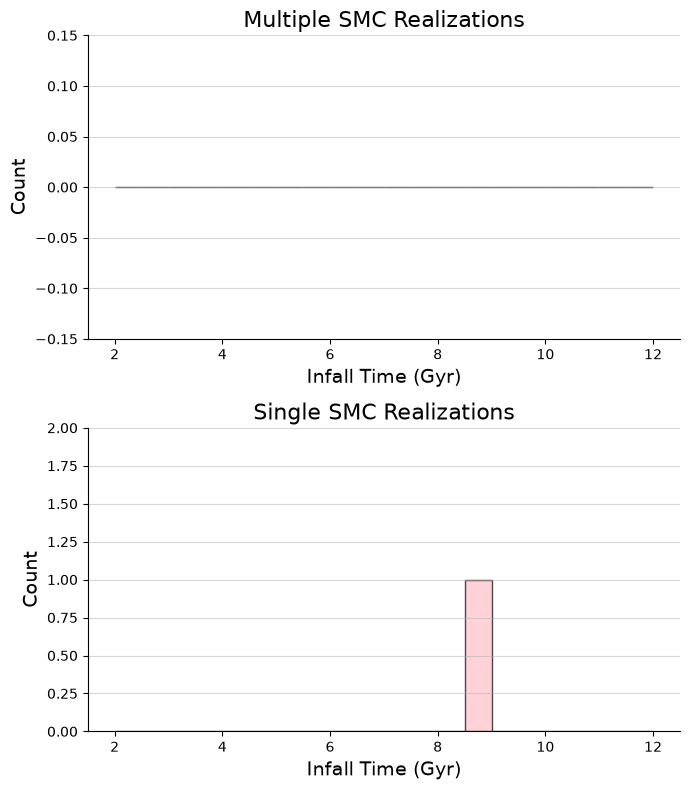

In [8]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Multiple SMC Realizations", fontsize=16)
ax[0].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Single SMC Realizations", fontsize=16)
ax[1].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



## KS Test

In [9]:
# from scipy.stats import ks_2samp
# ks_statistic, p_value = ks_2samp(special_candidates["basicTimeLastIsolated"], regular_candidates["basicTimeLastIsolated"])
# print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

# Mass Function

## Cummulative Mass Function

In [10]:
def cum_mass(m_sub):
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx) / total_tree_count
    return sorted_masses, N


## Generate Xs and Ys From Constrained

In [11]:
constrained_m_sub_bm = constrained_df["basicMass"].to_list()
constrained_x_bm, constrained_y_bm = cum_mass(constrained_m_sub_bm)

constrained_m_sub_sbm = constrained_df["satelliteBoundMass"].to_list()
constrained_x_sbm, constrained_y_sbm = cum_mass(constrained_m_sub_sbm)

print(constrained_x_bm)
print(constrained_y_bm)
print(constrained_x_sbm)
print(constrained_y_sbm)

[1.00170024e+07 1.00196838e+07 1.00199599e+07 ... 4.74823775e+11
 4.80441243e+11 4.81108064e+11]
[9.22382e+02 9.22381e+02 9.22380e+02 ... 2.00000e-03 1.00000e-03
 0.00000e+00]
[9.85805049e+06 9.87056794e+06 9.88317086e+06 ... 4.64741060e+11
 4.74916902e+11 4.81048932e+11]
[9.22382e+02 9.22381e+02 9.22380e+02 ... 2.00000e-03 1.00000e-03
 0.00000e+00]


## Generate Xs and Ys From Unconstrained

In [12]:
unconstrained_m_sub_bm = unconstrained_df["basicMass"].to_list()
unconstrained_x_bm, unconstrained_y_bm = cum_mass(unconstrained_m_sub_bm)

unconstrained_m_sub_sbm = unconstrained_df["satelliteBoundMass"].to_list()
unconstrained_x_sbm, unconstrained_y_sbm = cum_mass(unconstrained_m_sub_sbm)

print(unconstrained_x_bm)
print(unconstrained_y_bm)
print(unconstrained_x_sbm)
print(unconstrained_y_sbm)

[1.00031776e+07 1.00059794e+07 1.00161775e+07 ... 4.91694506e+11
 4.92379387e+11 4.94063404e+11]
[9.24305e+02 9.24304e+02 9.24303e+02 ... 2.00000e-03 1.00000e-03
 0.00000e+00]
[9.81078704e+06 9.86759091e+06 9.90792561e+06 ... 4.50376992e+11
 4.78339465e+11 4.91881892e+11]
[9.24305e+02 9.24304e+02 9.24303e+02 ... 2.00000e-03 1.00000e-03
 0.00000e+00]


## Make Mass Function Plots of Basic Masses vs Satellite Bound Masses

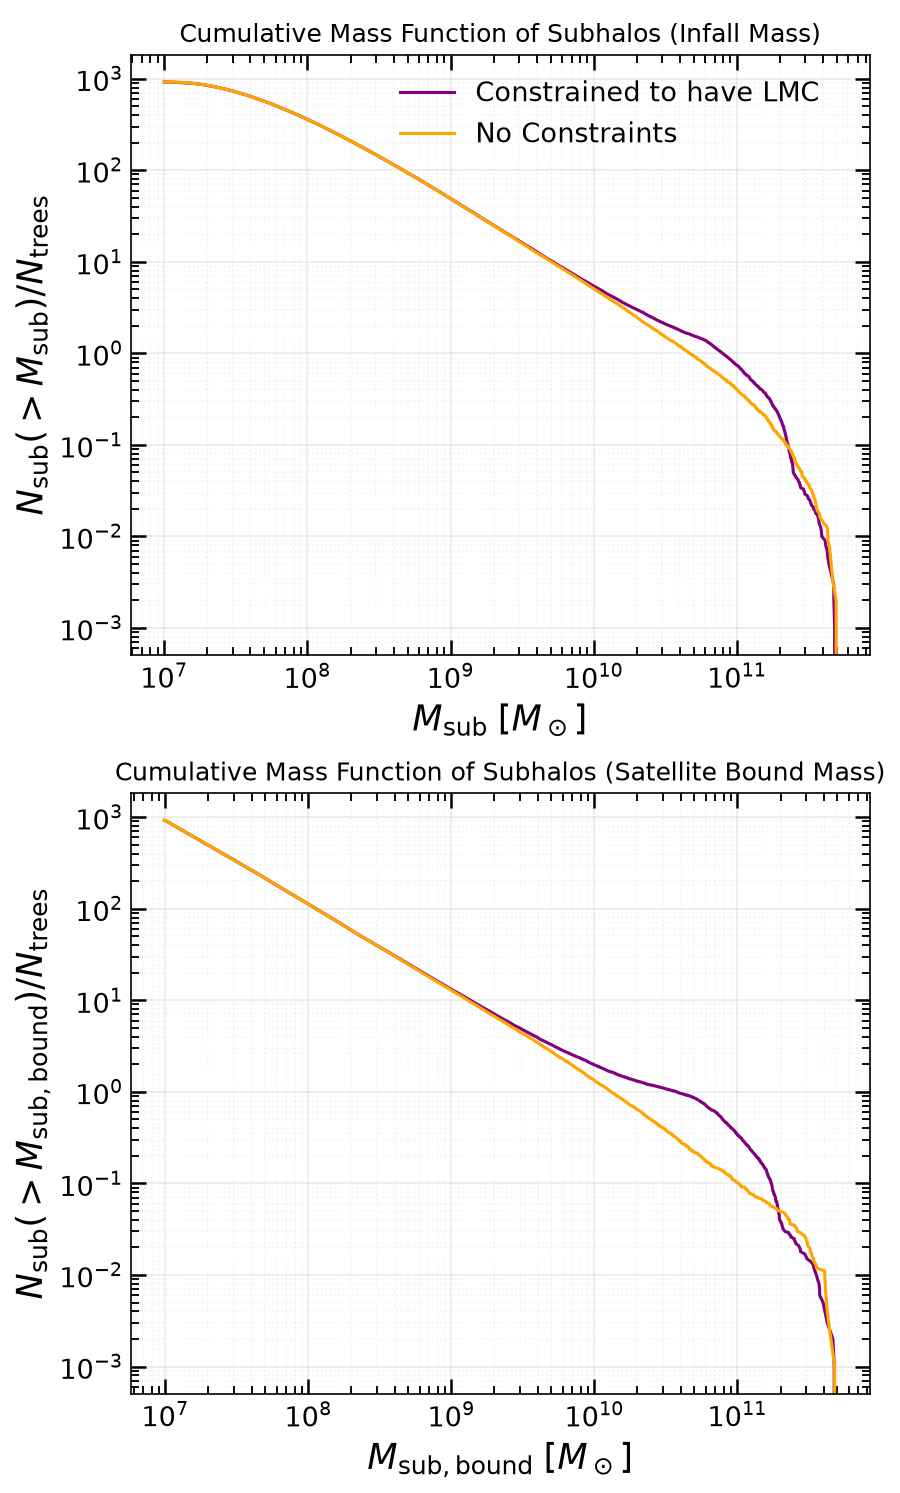

In [13]:
fig, ax = plt.subplots(2, 1, figsize= (6, 10), dpi= 150)

ax[0].plot(constrained_x_bm, constrained_y_bm, color= "purple")
ax[0].plot(unconstrained_x_bm, unconstrained_y_bm, color= "orange")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[0].set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax[0].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax[0].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[0].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[0].tick_params(top=True, right=True, which="both")

ax[0].grid(True, which="major", linestyle="-", alpha=0.25)
ax[0].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[0].title.set_text("Cumulative Mass Function of Subhalos (Infall Mass)")

ax[1].plot(constrained_x_sbm, constrained_y_sbm, color= "purple")
ax[1].plot(unconstrained_x_sbm, unconstrained_y_sbm, color= "orange")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_xlabel(r"$M_{\rm sub, bound}\;[M_\odot]$", fontsize=17)
ax[1].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub, bound})/ N_{\rm trees}$", fontsize=17)

ax[1].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[1].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[1].tick_params(top=True, right=True, which="both")

ax[1].grid(True, which="major", linestyle="-", alpha=0.25)
ax[1].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[1].title.set_text("Cumulative Mass Function of Subhalos (Satellite Bound Mass)")

fig.legend(["Constrained to have LMC", "No Constraints"], fontsize=13, loc="upper right", frameon=False, borderpad=2.5)
fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos vs Not Associated

In [14]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]

unbound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 0)
]
regular_unbound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 0)
]
special_unbound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 0)
]

print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print (unbound_smcs["tree_id"].to_list())
print (regular_unbound_smcs["tree_id"].to_list())
print (special_unbound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

[734]
[734]
[]
[682]
[682]
[]
Number of regular bound SMC candidates: 1
Number of special bound SMC candidates: 0
Number of bound SMC candidates: 1


## Spatial Directions of SMC Candidates

In [15]:
x_regular_bound = regular_bound_smcs["satellitePositionX"].to_list()
y_regular_bound = regular_bound_smcs["satellitePositionY"].to_list()
z_regular_bound = regular_bound_smcs["satellitePositionZ"].to_list()

x_special_bound = special_bound_smcs["satellitePositionX"].to_list()
y_special_bound = special_bound_smcs["satellitePositionY"].to_list()
z_special_bound = special_bound_smcs["satellitePositionZ"].to_list()

x_regular_unbound = regular_unbound_smcs["satellitePositionX"].to_list()
y_regular_unbound = regular_unbound_smcs["satellitePositionY"].to_list()
z_regular_unbound = regular_unbound_smcs["satellitePositionZ"].to_list()

x_special_unbound = special_unbound_smcs["satellitePositionX"].to_list()
y_special_unbound = special_unbound_smcs["satellitePositionY"].to_list()
z_special_unbound = special_unbound_smcs["satellitePositionZ"].to_list()

x_actual = 0.0164
y_actual = -0.0167
z_actual = -0.0154

## 3d Plot of Spatial Distributions of SMC Candidates

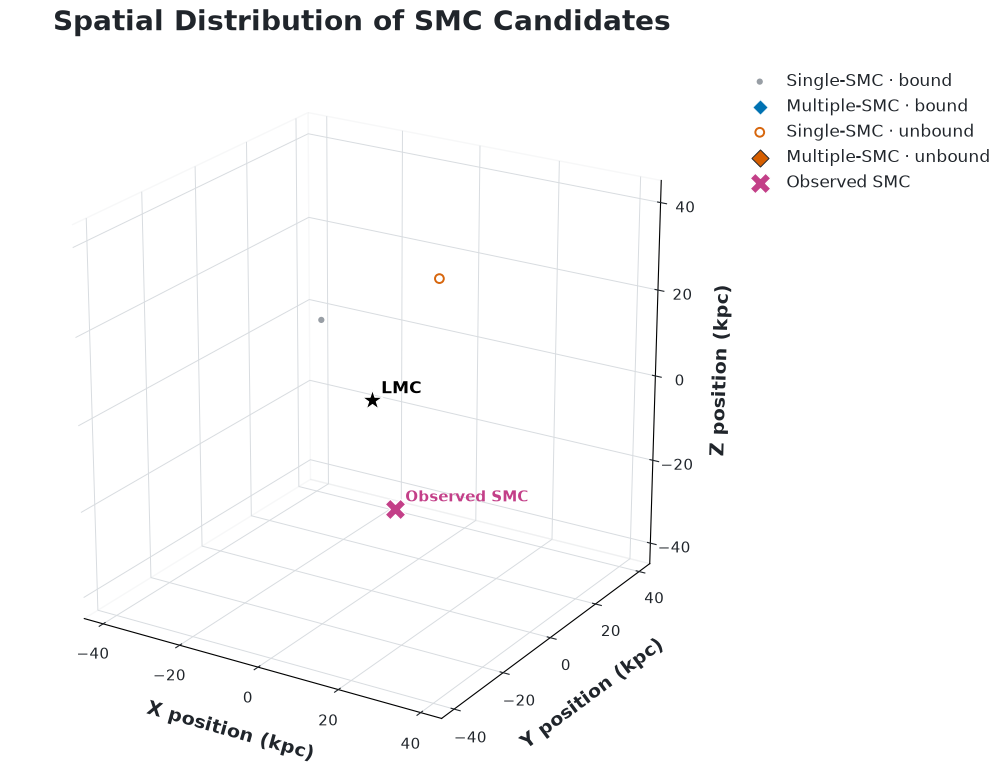

In [16]:
SINGLE_BOUND = "#68717A"
MULTIPLE_BOUND = "#0072B2"
UNBOUND = "#D55E00"
OBSERVED = "#C33F88"

TEXT = "#20252B"
AXIS = "#7C858D"
GRID = "#D8DCE0"


def kpc(values):
    return 1000.0 * np.asarray(values)


data = {
    "single_bound": (
        kpc(x_regular_bound),
        kpc(y_regular_bound),
        kpc(z_regular_bound),
    ),
    "multiple_bound": (
        kpc(x_special_bound),
        kpc(y_special_bound),
        kpc(z_special_bound),
    ),
    "single_unbound": (
        kpc(x_regular_unbound),
        kpc(y_regular_unbound),
        kpc(z_regular_unbound),
    ),
    "multiple_unbound": (
        kpc(x_special_unbound),
        kpc(y_special_unbound),
        kpc(z_special_unbound),
    ),
}

observed = np.array(
    [x_actual, y_actual, z_actual],
    dtype=float,
) * 1000.0


fig = plt.figure(
    figsize=(10.5, 8),
    facecolor="white",
)

ax = fig.add_subplot(
    111,
    projection="3d",
)


# Single-SMC, bound:
# darker gray background population
ax.scatter(
    *data["single_bound"],
    s=20,
    c=SINGLE_BOUND,
    marker="o",
    alpha=0.68,
    edgecolors="none",
    depthshade=False,
    rasterized=True,
    label="Single-SMC · bound",
)


# Single-SMC, unbound:
# hollow orange circles
ax.scatter(
    *data["single_unbound"],
    s=40,
    facecolors="none",
    edgecolors=UNBOUND,
    marker="o",
    alpha=0.95,
    linewidths=1.4,
    depthshade=False,
    rasterized=True,
    label="Single-SMC · unbound",
)


# Multiple-SMC, bound:
# blue diamonds
ax.scatter(
    *data["multiple_bound"],
    s=62,
    c=MULTIPLE_BOUND,
    marker="D",
    alpha=1.0,
    edgecolors="white",
    linewidths=0.7,
    depthshade=False,
    label="Multiple-SMC · bound",
)


# Multiple-SMC, unbound:
# filled orange diamonds with dark outlines
ax.scatter(
    *data["multiple_unbound"],
    s=76,
    c=UNBOUND,
    marker="D",
    alpha=1.0,
    edgecolors=TEXT,
    linewidths=0.7,
    depthshade=False,
    label="Multiple-SMC · unbound",
)


# LMC at the origin
ax.scatter(
    [0],
    [0],
    [0],
    s=240,
    c="black",
    marker="*",
    edgecolors="white",
    linewidths=0.9,
    depthshade=False,
    label="_nolegend_",
)


# Observed SMC
ax.scatter(
    [observed[0]],
    [observed[1]],
    [observed[2]],
    s=220,
    c=OBSERVED,
    marker="X",
    edgecolors="white",
    linewidths=0.9,
    depthshade=False,
    label="Observed SMC",
)


# Reference-object labels
ax.text(
    1.5,
    1.5,
    1.5,
    "LMC",
    fontsize=12,
    fontweight="bold",
    color="black",
)

ax.text(
    observed[0] + 1.5,
    observed[1] + 1.5,
    observed[2] + 1.5,
    "Observed SMC",
    fontsize=11,
    fontweight="bold",
    color=OBSERVED,
)


ax.set_title(
    "Spatial Distribution of SMC Candidates",
    fontsize=20,
    fontweight="bold",
    color=TEXT,
    pad=20,
)

ax.set_xlabel(
    "X position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)

ax.set_ylabel(
    "Y position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)

ax.set_zlabel(
    "Z position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)


ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_zlim(-45, 45)

ticks = [-40, -20, 0, 20, 40]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)

ax.tick_params(
    labelsize=11,
    colors=TEXT,
)

ax.view_init(
    elev=22,
    azim=-58,
)

ax.set_box_aspect((1, 1, 1))


# Light panes and subtle gridlines
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 1))
    axis.pane.set_edgecolor(AXIS)
    axis.pane.set_alpha(0.06)

    axis._axinfo["grid"]["color"] = GRID
    axis._axinfo["grid"]["linewidth"] = 0.7


# Match the category order used in the 2D legend
handles, labels = ax.get_legend_handles_labels()

legend_order = [0, 2, 1, 3, 4]

ax.legend(
    [handles[i] for i in legend_order],
    [labels[i] for i in legend_order],
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=12,
    labelcolor=TEXT,
    handletextpad=0.6,
)

fig.subplots_adjust(
    left=0.02,
    right=0.78,
    bottom=0.04,
    top=0.92,
)

plt.show()

## Plot of Different Projections

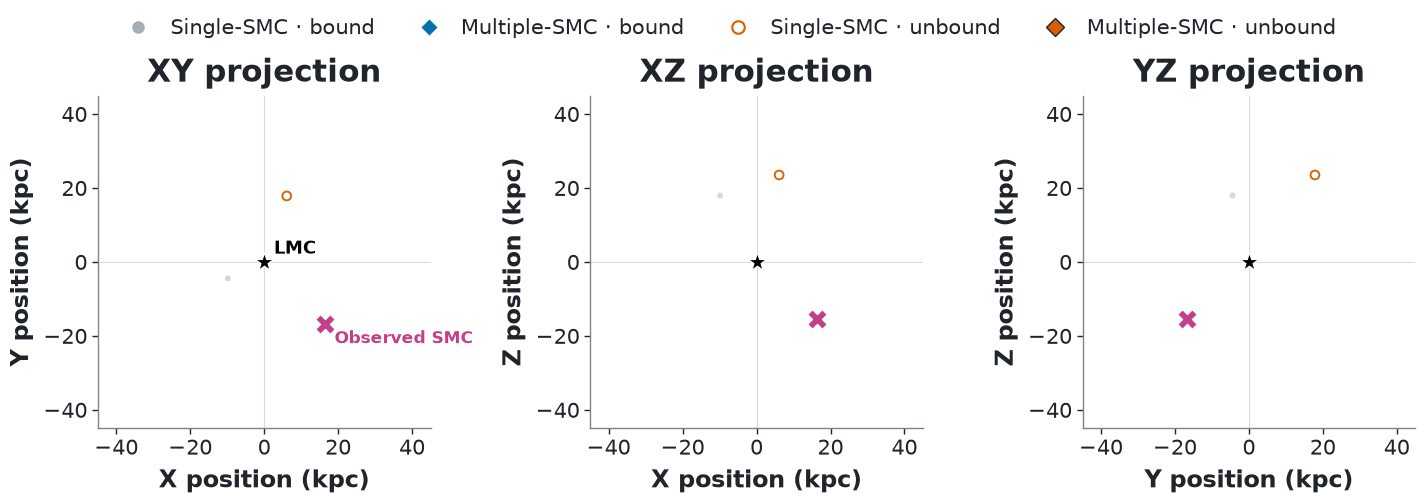

In [17]:
from matplotlib.lines import Line2D

# Color-blind-friendly hierarchy:
# gray = background population
# blue = multiple-SMC system
# orange = unbound from LMC
# magenta = observed SMC
SINGLE_BOUND = "#A7ADB4"
MULTIPLE_BOUND = "#0072B2"
UNBOUND = "#D55E00"
OBSERVED = "#C33F88"
TEXT = "#20252B"
AXIS = "#7C858D"
ZERO_LINE = "#D8DCE0"


def kpc(values):
    return 1000.0 * np.asarray(values)


data = {
    "single_bound": (
        kpc(x_regular_bound),
        kpc(y_regular_bound),
        kpc(z_regular_bound),
    ),
    "multiple_bound": (
        kpc(x_special_bound),
        kpc(y_special_bound),
        kpc(z_special_bound),
    ),
    "single_unbound": (
        kpc(x_regular_unbound),
        kpc(y_regular_unbound),
        kpc(z_regular_unbound),
    ),
    "multiple_unbound": (
        kpc(x_special_unbound),
        kpc(y_special_unbound),
        kpc(z_special_unbound),
    ),
}

observed = np.array(
    [x_actual, y_actual, z_actual],
    dtype=float,
) * 1000.0

projections = [
    ("XY", 0, 1, "X position (kpc)", "Y position (kpc)"),
    ("XZ", 0, 2, "X position (kpc)", "Z position (kpc)"),
    ("YZ", 1, 2, "Y position (kpc)", "Z position (kpc)"),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5.2),
    facecolor="white",
)

for panel_number, (
    ax,
    (title, horizontal, vertical, xlabel, ylabel),
) in enumerate(zip(axes, projections)):

    # Subtle origin guides
    ax.axhline(
        0,
        color=ZERO_LINE,
        linewidth=0.8,
        zorder=0,
    )
    ax.axvline(
        0,
        color=ZERO_LINE,
        linewidth=0.8,
        zorder=0,
    )

    # 1. Single-SMC, bound:
    # neutral background population
    ax.scatter(
        data["single_bound"][horizontal],
        data["single_bound"][vertical],
        s=18,
        c=SINGLE_BOUND,
        marker="o",
        alpha=0.48,
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )

    # 2. Single-SMC, unbound:
    # hollow orange circles
    ax.scatter(
        data["single_unbound"][horizontal],
        data["single_unbound"][vertical],
        s=40,
        facecolors="none",
        edgecolors=UNBOUND,
        marker="o",
        alpha=0.95,
        linewidths=1.4,
        rasterized=True,
        zorder=3,
    )

    # 3. Multiple-SMC, bound:
    # blue diamonds
    ax.scatter(
        data["multiple_bound"][horizontal],
        data["multiple_bound"][vertical],
        s=62,
        c=MULTIPLE_BOUND,
        marker="D",
        alpha=1.0,
        edgecolors="white",
        linewidths=0.7,
        zorder=4,
    )

    # 4. Multiple-SMC, unbound:
    # filled orange diamonds with dark outlines
    ax.scatter(
        data["multiple_unbound"][horizontal],
        data["multiple_unbound"][vertical],
        s=76,
        c=UNBOUND,
        marker="D",
        alpha=1.0,
        edgecolors=TEXT,
        linewidths=0.7,
        zorder=5,
    )

    # LMC at the origin
    ax.scatter(
        0,
        0,
        s=200,
        c="black",
        marker="*",
        edgecolors="white",
        linewidths=0.9,
        zorder=7,
    )

    # Observed SMC
    ax.scatter(
        observed[horizontal],
        observed[vertical],
        s=200,
        c=OBSERVED,
        marker="X",
        edgecolors="white",
        linewidths=0.9,
        zorder=8,
    )

    # Label reference objects only once
    if panel_number == 0:
        ax.annotate(
            "LMC",
            (0, 0),
            xytext=(7, 6),
            textcoords="offset points",
            fontsize=13,
            fontweight="bold",
            color="black",
            zorder=9,
        )

        ax.annotate(
            "Observed SMC",
            (observed[horizontal], observed[vertical]),
            xytext=(7, -14),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
            color=OBSERVED,
            zorder=9,
        )

    ax.set_title(
        f"{title} projection",
        fontsize=22,
        fontweight="bold",
        color=TEXT,
        pad=10,
    )

    ax.set_xlabel(
        xlabel,
        fontsize=17,
        fontweight="bold",
        color=TEXT,
        labelpad=7,
    )
    ax.set_ylabel(
        ylabel,
        fontsize=17,
        fontweight="bold",
        color=TEXT,
        labelpad=7,
    )

    ax.set_xlim(-45, 45)
    ax.set_ylim(-45, 45)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([-40, -20, 0, 20, 40])

    ax.tick_params(
        axis="both",
        labelsize=15,
        colors=TEXT,
        width=1.0,
        length=4,
    )

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)


legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=SINGLE_BOUND,
        markeredgecolor="none",
        markersize=9,
        label="Single-SMC · bound",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=MULTIPLE_BOUND,
        markeredgecolor="white",
        markersize=9,
        label="Multiple-SMC · bound",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor=UNBOUND,
        markeredgewidth=1.5,
        markersize=9,
        label="Single-SMC · unbound",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=UNBOUND,
        markeredgecolor=TEXT,
        markersize=9,
        label="Multiple-SMC · unbound",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=4,
    frameon=False,
    fontsize=15,
    handletextpad=0.55,
    columnspacing=1.6,
    labelcolor=TEXT,
)

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    bottom=0.15,
    top=0.79,
    wspace=0.20,
)


plt.show()

## Histogram of Absolute Distances of SMC Candidates

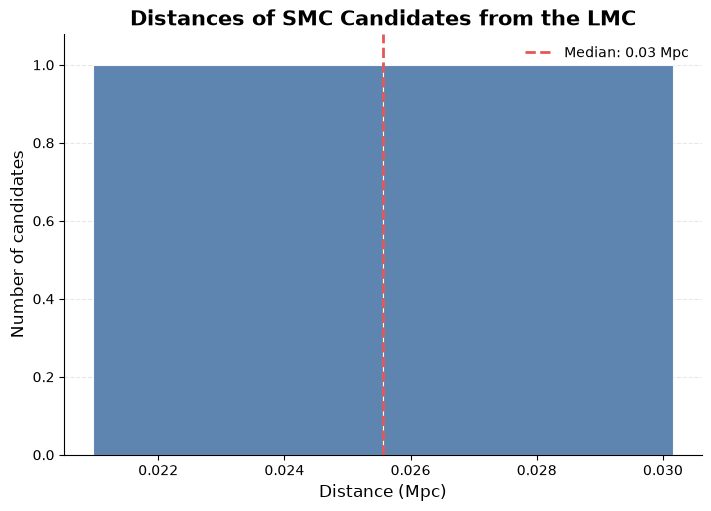

In [18]:
distances = selected["absolute_distance"].dropna()

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax.hist(
    distances,
    bins="auto",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

median_distance = distances.median()
ax.axvline(
    median_distance,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_distance:.2f} Mpc",
)

ax.set(
    title="Distances of SMC Candidates from the LMC",
    xlabel="Distance (Mpc)",
    ylabel="Number of candidates",
)

ax.title.set_fontsize(15)
ax.title.set_weight("bold")
ax.xaxis.label.set_fontsize(12)
ax.yaxis.label.set_fontsize(12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.margins(y=0.08)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

## Constrained and Unconstrained SMC Concentrations

In [19]:
constrained_concentration = constrained_df["darkMatterOnlyRadiusVirial"] / constrained_df["darkMatterProfileScale"]
unconstrained_concentration = unconstrained_df["darkMatterOnlyRadiusVirial"] / unconstrained_df["darkMatterProfileScale"]

## Histograms of Concentrations